In [1]:
%matplotlib inline
import pandas as pd
columns = [    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty_level"]

df = pd.read_csv("NSLKDDdataset/KDDTrain+.txt", names=columns)

print (df.shape)
df.head()

(125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
import os
print(os.listdir("."))

['.git', '.gitignore', '.ipynb_checkpoints', '01_exploration.ipynb', 'data_cleaned.csv', 'NSLKDDdataset', 'README.md', 'venv']


In [3]:
print(df.head())
print(df.describe())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [4]:
print ( df.isnull().sum().sum())
print (df.duplicated().sum())

0
0


In [5]:
print (df["label"].value_counts())


label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [6]:
df['attack_flag'] = df['label'].apply (lambda x:0 if x == 'normal' else 1)
print (df['attack_flag'].value_counts())

attack_flag
0    67343
1    58630
Name: count, dtype: int64


In [7]:
df_clean = df.copy()


In [8]:
df_clean = pd.get_dummies(
    df_clean,
 columns = ["protocol_type", "service", "flag"],
    dtype = int
    )

In [9]:
df_clean = df_clean.drop(columns = ["label"] ,
                        errors = "ignore")
df_clean.head()


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,146,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,232,8153,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,199,420,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


In [10]:
print(df_clean.columns.tolist())

['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty_level', 'attack_flag', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'ser

In [11]:
df_clean.to_csv("data_cleaned.csv" , index = False )

In [12]:
print(df_clean.shape)


(125973, 124)


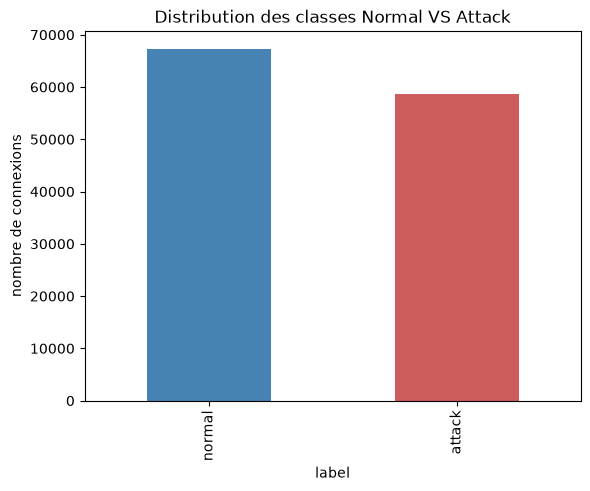

In [13]:
import matplotlib.pyplot as plt
df['label'].apply(lambda x:'normal' if x == 'normal' else 'attack').value_counts().plot( 
kind = 'bar' , color = ['steelblue','indianred']
)
plt.title('Distribution des classes Normal VS Attack')
plt.ylabel('nombre de connexions')
plt.show()

In [14]:
correlation = df_clean.corr(numeric_only=True)['attack_flag'].sort_values(ascending=False)
print(correlation.head(10))
print(correlation.tail(10))

attack_flag                 1.000000
dst_host_srv_serror_rate    0.654985
dst_host_serror_rate        0.651842
serror_rate                 0.650652
flag_S0                     0.650206
srv_serror_rate             0.648289
count                       0.576444
service_private             0.449720
dst_host_count              0.375052
srv_rerror_rate             0.253504
Name: attack_flag, dtype: float64
protocol_type_udp        -0.217184
service_domain_u         -0.258927
difficulty_level         -0.379707
service_http             -0.562312
logged_in                -0.690171
dst_host_same_srv_rate   -0.693803
dst_host_srv_count       -0.722535
same_srv_rate            -0.751913
flag_SF                  -0.756286
num_outbound_cmds              NaN
Name: attack_flag, dtype: float64


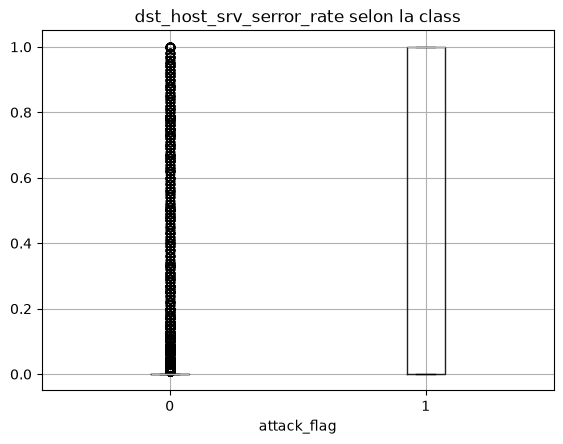

In [15]:
top_feature=correlation.index[1]
df_clean.boxplot(column=top_feature,
                 by='attack_flag')
plt.title(f'{top_feature} selon la class')
plt.suptitle('')
plt.show()


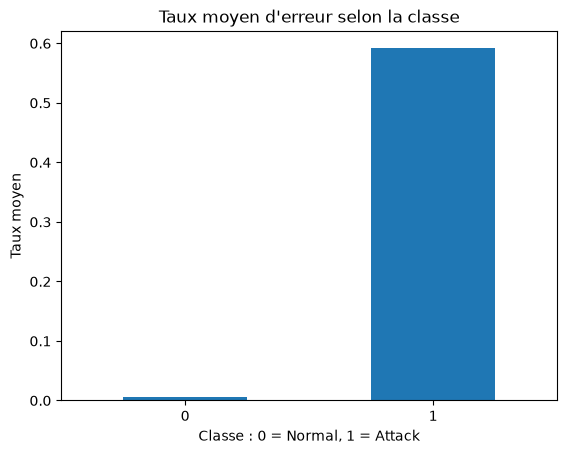

In [16]:
df_clean.groupby("attack_flag")["dst_host_srv_serror_rate"].mean().plot(
    kind="bar"
)

plt.title("Taux moyen d'erreur selon la classe")
plt.xlabel("Classe : 0 = Normal, 1 = Attack")
plt.ylabel("Taux moyen")
plt.xticks(rotation=0)
plt.show()

In [17]:
X=df_clean.drop(columns=['attack_flag', 'difficulty_level'])
y=df_clean['attack_flag']
print(X.shape , y.shape)

(125973, 122) (125973,)


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2 , 
    stratify=y ,
    random_state=42)
print('train', X_train.shape,'test',X_test.shape)

train (100778, 122) test (25195, 122)


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
    

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     13469
           1       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195

[[13199   270]
 [  429 11297]]


In [21]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators =100,
    max_depth=20,
    random_state=42)
rf_model.fit(X_train_scaled,y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

[[13463     6]
 [   20 11706]]


In [22]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42,eval_metric='logloss')
xgb_model=xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb= xgb_model.predict(X_test_scaled )
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [23]:

errors = X_test.copy()
errors['true']=y_test.values
errors['pred']=y_pred_xgb
missclasified = errors[errors['true']!=errors['pred']]
print(f"nombre d erreurs:{len(missclasified)}sur{len(errors)}")



nombre d erreurs:19sur25195


In [24]:
print(missclasified.head())


        duration  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  \
66013          0          0          0     0               0       0    0   
62554          0          0          0     1               0       0    0   
1143           0        564          0     0               0       0    0   
21323          0          0          0     0               0       0    0   
109088         0          0       2072     0               0       0    1   

        num_failed_logins  logged_in  num_compromised  ...  flag_RSTOS0  \
66013                   0          0                0  ...            0   
62554                   0          0                0  ...            0   
1143                    0          0                0  ...            0   
21323                   0          0                0  ...            0   
109088                  0          1                0  ...            0   

        flag_RSTR  flag_S0  flag_S1  flag_S2  flag_S3  flag_SF  flag_SH  true  \
66013

In [25]:
from sklearn.metrics import accuracy_score , f1_score , precision_score, recall_score
results = pd.DataFrame({
    'Modele':['logisticRegression', 'RandomForst', 'XGB'],
    'accuracy':[accuracy_score(y_test,y_pred),
                accuracy_score(y_test,y_pred_rf),
                accuracy_score(y_test,y_pred_xgb)],
    'f1_score':[f1_score(y_test,y_pred),
                f1_score(y_test,y_pred_rf),
                f1_score(y_test,y_pred_xgb)],
    'precision':[precision_score(y_test,y_pred),
                 precision_score(y_test,y_pred_rf),
                 precision_score(y_test,y_pred_xgb)],
    'recall_score':[recall_score(y_test,y_pred),
                    recall_score(y_test,y_pred_rf),
                    recall_score(y_test,y_pred_xgb)]
        })
print(results)
        

               Modele  accuracy  f1_score  precision  recall_score
0  logisticRegression  0.972256  0.969991   0.976658      0.963415
1         RandomForst  0.998968  0.998891   0.999488      0.998294
2                 XGB  0.999246  0.999190   0.999232      0.999147


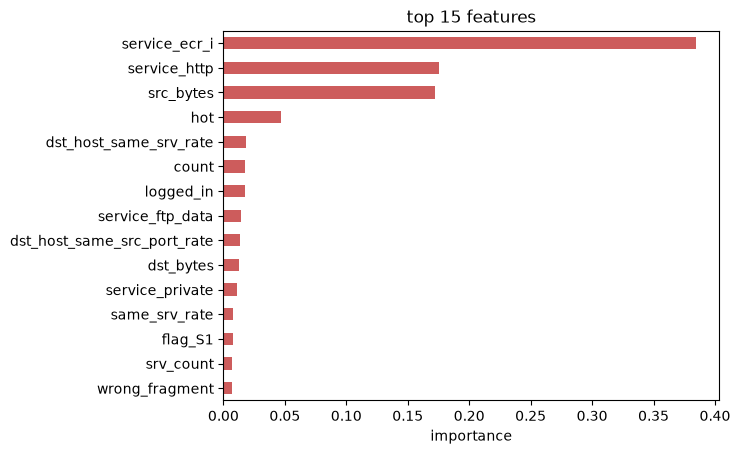

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
feature_importance = pd.Series( xgb_model.feature_importances_,index=X_train.columns).sort_values(ascending=False)
feature_importance.head(15)
feature_importance.head(15).plot(
    kind ='barh',
    color='indianred'
)
plt.title('top 15 features')
plt.xlabel('importance')
plt.gca().invert_yaxis()
plt.show()